In [ ]:
# Run this in Colab to create folders and upload
from google.colab import files
import os
import zipfile
import shutil

# Create directory structure
os.makedirs('/content/pet_data/breeds/persian', exist_ok=True)
os.makedirs('/content/pet_data/breeds/siamese', exist_ok=True)
os.makedirs('/content/pet_data/breeds/maine_coon', exist_ok=True)
os.makedirs('/content/pet_data/breeds/bengal', exist_ok=True)
os.makedirs('/content/pet_data/breeds/mixed', exist_ok=True)

os.makedirs('/content/pet_data/skin/healthy', exist_ok=True)
os.makedirs('/content/pet_data/skin/fungal', exist_ok=True)
os.makedirs('/content/pet_data/skin/redness', exist_ok=True)
os.makedirs('/content/pet_data/skin/scabies', exist_ok=True)
os.makedirs('/content/pet_data/skin/dandruff', exist_ok=True)

os.makedirs('/content/pet_data/demo', exist_ok=True)

print("✅ Folders created!")

# OPTION 1: Upload images as zip (recommended)
print("\n📁 Please upload your images as a ZIP file")
print("If you have a zip file, run this cell and select your file:")

uploaded = files.upload()

# If you uploaded a zip file, unzip it
for filename in uploaded.keys():
    if filename.endswith('.zip'):
        with zipfile.ZipFile(filename, 'r') as zip_ref:
            zip_ref.extractall('/content/pet_data/')
        print(f"✅ Unzipped {filename}")

# OPTION 2: Upload images individually (if no zip)
print("\n📸 OR upload images one by one to specific folders:")

def upload_to_folder(folder_path):
    print(f"Upload to: {folder_path}")
    uploaded = files.upload()
    for filename in uploaded.keys():
        shutil.move(filename, os.path.join(folder_path, filename))
    print(f"✅ Added {len(uploaded)} images to {folder_path}")

# Uncomment below to upload to each folder (if you didn't use zip)
# upload_to_folder('/content/pet_data/breeds/persian/')
# upload_to_folder('/content/pet_data/breeds/siamese/')
# etc.

✅ Folders created!

📁 Please upload your images as a ZIP file
If you have a zip file, run this cell and select your file:


Saving dataset.zip to dataset (1).zip
✅ Unzipped dataset (1).zip

📸 OR upload images one by one to specific folders:


In [ ]:
# Run this to install everything we need
!pip install tensorflow matplotlib numpy pandas flask-ngrok pyngrok pillow opencv-python

# Check if GPU is available
import tensorflow as tf
print("GPU Available:", tf.config.list_physical_devices('GPU'))
print("TensorFlow version:", tf.__version__)

GPU Available: []
TensorFlow version: 2.19.0


In [1]:
# Run this first to extract your uploaded zip
import zipfile
import os

# Check what files were uploaded
!ls -la

# Find your zip file (it might have a different name)
zip_files = [f for f in os.listdir() if f.endswith('.zip')]
print("Found zip files:", zip_files)

if zip_files:
    zip_name = zip_files[0]  # Use the first zip file
    print(f"Extracting: {zip_name}")

    with zipfile.ZipFile(zip_name, 'r') as zip_ref:
        zip_ref.extractall('/content/pet_data')
    print("✅ Extraction complete!")

    # Show what was extracted
    !ls -la /content/pet_data
else:
    print("❌ No zip file found. Please upload your zip file first.")

total 3528
drwxr-xr-x 1 root root    4096 Mar 16 17:02 .
drwxr-xr-x 1 root root    4096 Mar 16 17:00 ..
drwxr-xr-x 4 root root    4096 Jan 16 14:24 .config
-rw-r--r-- 1 root root 3593991 Mar 16 17:02 dataset.zip
drwxr-xr-x 1 root root    4096 Jan 16 14:24 sample_data
Found zip files: ['dataset.zip']
Extracting: dataset.zip
✅ Extraction complete!
total 12
drwxr-xr-x 3 root root 4096 Mar 16 17:02 .
drwxr-xr-x 1 root root 4096 Mar 16 17:02 ..
drwxr-xr-x 5 root root 4096 Mar 16 17:02 dataset


In [2]:
# Install all needed packages
!pip install tensorflow matplotlib numpy gradio pillow opencv-python

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import matplotlib.pyplot as plt
import os
import glob
from PIL import Image
import cv2

print("✅ Libraries installed and imported")
print("GPU Available:", tf.config.list_physical_devices('GPU'))

✅ Libraries installed and imported
GPU Available: []


In [3]:
# Check your folder structure and count images

# Define categories based on your folder names
breed_categories = ['persian', 'siamese', 'maine_coon', 'bengal', 'mixed']
skin_categories = ['healthy', 'fungal', 'redness', 'scabies', 'dandruff']

print("📁 CHECKING BREED FOLDERS:")
for breed in breed_categories:
    path = f'/content/pet_data/breeds/{breed}/*.jpg'
    images = glob.glob(path)
    if not images:
        # Try other extensions
        images = glob.glob(f'/content/pet_data/breeds/{breed}/*.jpeg')
        images += glob.glob(f'/content/pet_data/breeds/{breed}/*.png')
    print(f"{breed}: {len(images)} images")

print("\n📁 CHECKING SKIN FOLDERS:")
for skin in skin_categories:
    path = f'/content/pet_data/skin/{skin}/*.jpg'
    images = glob.glob(path)
    if not images:
        images = glob.glob(f'/content/pet_data/skin/{skin}/*.jpeg')
        images += glob.glob(f'/content/pet_data/skin/{skin}/*.png')
    print(f"{skin}: {len(images)} images")

print("\n📁 CHECKING DEMO FOLDER:")
demo_images = glob.glob('/content/pet_data/demo/*.jpg')
demo_images += glob.glob('/content/pet_data/demo/*.jpeg')
demo_images += glob.glob('/content/pet_data/demo/*.png')
print(f"demo: {len(demo_images)} images")

📁 CHECKING BREED FOLDERS:
persian: 0 images
siamese: 0 images
maine_coon: 0 images
bengal: 0 images
mixed: 0 images

📁 CHECKING SKIN FOLDERS:
healthy: 0 images
fungal: 0 images
redness: 0 images
scabies: 0 images
dandruff: 0 images

📁 CHECKING DEMO FOLDER:
demo: 0 images


In [4]:
import os
import glob

print("="*60)
print("🔍 CHECKING ALL FILE NAMES IN YOUR FOLDERS")
print("="*60)

# Define all folders to check
folders_to_check = [
    '/content/pet_data/breeds/persian',
    '/content/pet_data/breeds/siamese',
    '/content/pet_data/breeds/maine_coon',
    '/content/pet_data/breeds/bengal',
    '/content/pet_data/breeds/mixed',
    '/content/pet_data/skin/healthy',
    '/content/pet_data/skin/fungal',
    '/content/pet_data/skin/redness',
    '/content/pet_data/skin/scabies',
    '/content/pet_data/skin/dandruff',
    '/content/pet_data/demo'
]

# Check each folder
for folder in folders_to_check:
    print(f"\n📁 FOLDER: {folder}")
    print("-" * 40)

    if os.path.exists(folder):
        # Get all image files
        image_files = []
        for ext in ['*.jpg', '*.jpeg', '*.JPG', '*.JPEG', '*.png', '*.PNG']:
            image_files.extend(glob.glob(os.path.join(folder, ext)))

        if image_files:
            print(f"✅ Found {len(image_files)} images:")
            for i, img_file in enumerate(image_files[:5]):  # Show first 5 only
                filename = os.path.basename(img_file)
                size = os.path.getsize(img_file) / 1024  # Size in KB
                print(f"   {i+1}. {filename} ({size:.1f} KB)")

            if len(image_files) > 5:
                print(f"   ... and {len(image_files)-5} more images")
        else:
            print("❌ No images found in this folder")
    else:
        print("❌ Folder does not exist")

print("\n" + "="*60)
print("📊 SUMMARY TABLE")
print("="*60)

# Create a summary table
print(f"{'Folder':<30} {'Count':<10} {'Status':<10}")
print("-"*50)

for folder in folders_to_check:
    folder_name = folder.replace('/content/pet_data/', '')
    if os.path.exists(folder):
        image_count = 0
        for ext in ['*.jpg', '*.jpeg', '*.JPG', '*.JPEG', '*.png', '*.PNG']:
            image_count += len(glob.glob(os.path.join(folder, ext)))

        if image_count > 0:
            print(f"{folder_name:<30} {image_count:<10} ✅ OK")
        else:
            print(f"{folder_name:<30} {0:<10} ❌ No images")
    else:
        print(f"{folder_name:<30} {'-':<10} ❌ Missing")

print("="*60)

🔍 CHECKING ALL FILE NAMES IN YOUR FOLDERS

📁 FOLDER: /content/pet_data/breeds/persian
----------------------------------------
❌ Folder does not exist

📁 FOLDER: /content/pet_data/breeds/siamese
----------------------------------------
❌ Folder does not exist

📁 FOLDER: /content/pet_data/breeds/maine_coon
----------------------------------------
❌ Folder does not exist

📁 FOLDER: /content/pet_data/breeds/bengal
----------------------------------------
❌ Folder does not exist

📁 FOLDER: /content/pet_data/breeds/mixed
----------------------------------------
❌ Folder does not exist

📁 FOLDER: /content/pet_data/skin/healthy
----------------------------------------
❌ Folder does not exist

📁 FOLDER: /content/pet_data/skin/fungal
----------------------------------------
❌ Folder does not exist

📁 FOLDER: /content/pet_data/skin/redness
----------------------------------------
❌ Folder does not exist

📁 FOLDER: /content/pet_data/skin/scabies
----------------------------------------
❌ Folder d

In [5]:
import os
import zipfile
import glob
from pathlib import Path

print("="*60)
print("🔍 CHECKING YOUR UPLOADED FILES")
print("="*60)

# Step 1: Check what files are in current directory
print("\n📂 FILES IN CURRENT DIRECTORY:")
print("-" * 40)
current_files = os.listdir()
for file in current_files:
    size = os.path.getsize(file) / (1024*1024)  # Size in MB
    if os.path.isfile(file):
        print(f"📄 {file} - {size:.2f} MB")
    elif os.path.isdir(file):
        print(f"📁 {file}/")

# Step 2: Check if there's a zip file
print("\n🔍 LOOKING FOR ZIP FILES:")
print("-" * 40)
zip_files = [f for f in current_files if f.endswith('.zip')]
if zip_files:
    for zip_file in zip_files:
        size = os.path.getsize(zip_file) / (1024*1024)
        print(f"✅ Found zip: {zip_file} ({size:.2f} MB)")

        # Step 3: Peek inside the zip without extracting
        print(f"\n🔍 CONTENTS OF {zip_file}:")
        print("-" * 40)
        with zipfile.ZipFile(zip_file, 'r') as zip_ref:
            file_list = zip_ref.namelist()
            # Show first 20 files
            for i, file in enumerate(file_list[:20]):
                print(f"   {file}")
            if len(file_list) > 20:
                print(f"   ... and {len(file_list)-20} more files")

            # Count files by type
            jpg_count = len([f for f in file_list if f.lower().endswith('.jpg')])
            jpeg_count = len([f for f in file_list if f.lower().endswith('.jpeg')])
            png_count = len([f for f in file_list if f.lower().endswith('.png')])
            folder_count = len([f for f in file_list if f.endswith('/')])

            print(f"\n📊 ZIP SUMMARY:")
            print(f"   Total items: {len(file_list)}")
            print(f"   Folders: {folder_count}")
            print(f"   JPG images: {jpg_count}")
            print(f"   JPEG images: {jpeg_count}")
            print(f"   PNG images: {png_count}")
else:
    print("❌ No zip files found")

# Step 4: Check if pet_data folder exists
print("\n🔍 CHECKING FOR PET_DATA FOLDER:")
print("-" * 40)
if os.path.exists('/content/pet_data'):
    print("✅ pet_data folder exists")

    # Walk through pet_data
    print("\n📁 STRUCTURE OF pet_data:")
    print("-" * 40)
    for root, dirs, files in os.walk('/content/pet_data'):
        level = root.replace('/content/pet_data', '').count(os.sep)
        indent = ' ' * 4 * level
        print(f"{indent}📁 {os.path.basename(root)}/")
        subindent = ' ' * 4 * (level + 1)
        for file in files[:5]:  # Show first 5 files in each folder
            print(f"{subindent}📄 {file}")
        if len(files) > 5:
            print(f"{subindent}... and {len(files)-5} more files")
else:
    print("❌ pet_data folder not found")

# Step 5: Check specific breed and skin folders
print("\n🔍 CHECKING REQUIRED FOLDERS:")
print("-" * 40)

required_folders = [
    '/content/pet_data/breeds/persian',
    '/content/pet_data/breeds/siamese',
    '/content/pet_data/breeds/maine_coon',
    '/content/pet_data/breeds/bengal',
    '/content/pet_data/breeds/mixed',
    '/content/pet_data/skin/healthy',
    '/content/pet_data/skin/fungal',
    '/content/pet_data/skin/redness',
    '/content/pet_data/skin/scabies',
    '/content/pet_data/skin/dandruff',
    '/content/pet_data/demo'
]

for folder in required_folders:
    if os.path.exists(folder):
        images = []
        for ext in ['*.jpg', '*.jpeg', '*.JPG', '*.JPEG', '*.png', '*.PNG']:
            images.extend(glob.glob(os.path.join(folder, ext)))

        if images:
            print(f"✅ {folder:40} - {len(images)} images")
            # Show first image name as example
            print(f"   Example: {os.path.basename(images[0])}")
        else:
            print(f"⚠️  {folder:40} - Folder exists but no images")
    else:
        print(f"❌ {folder:40} - Missing")

# Step 6: Check for any files in wrong locations
print("\n🔍 CHECKING FOR MISPLACED FILES:")
print("-" * 40)

# Look for images outside the expected structure
all_images = []
for root, dirs, files in os.walk('/content'):
    for file in files:
        if file.lower().endswith(('.jpg', '.jpeg', '.png')):
            all_images.append(os.path.join(root, file))

print(f"Total images found in /content: {len(all_images)}")

# Show images that might be in wrong places
misplaced = [img for img in all_images if 'pet_data' not in img]
if misplaced:
    print(f"⚠️  Found {len(misplaced)} images outside pet_data folder:")
    for img in misplaced[:5]:
        print(f"   {img}")
else:
    print("✅ All images are inside pet_data folder")

# Step 7: Summary
print("\n" + "="*60)
print("📊 FINAL SUMMARY")
print("="*60)

# Count total images in correct structure
total_images = 0
for folder in required_folders:
    if os.path.exists(folder):
        for ext in ['*.jpg', '*.jpeg', '*.JPG', '*.JPEG', '*.png', '*.PNG']:
            total_images += len(glob.glob(os.path.join(folder, ext)))

print(f"Total images in correct folders: {total_images}")

if total_images >= 79:
    print("✅ You have all 79 images properly organized!")
elif total_images > 0:
    print(f"⚠️  You have {total_images} images (you mentioned 79 earlier)")
else:
    print("❌ No images found in the required folders")

print("\n" + "="*60)

🔍 CHECKING YOUR UPLOADED FILES

📂 FILES IN CURRENT DIRECTORY:
----------------------------------------
📁 .config/
📄 dataset.zip - 3.43 MB
📁 pet_data/
📁 sample_data/

🔍 LOOKING FOR ZIP FILES:
----------------------------------------
✅ Found zip: dataset.zip (3.43 MB)

🔍 CONTENTS OF dataset.zip:
----------------------------------------
   dataset/
   dataset/breeds/
   dataset/breeds/Bengal/
   dataset/breeds/Bengal/bengal_01.jpeg
   dataset/breeds/Bengal/bengal_02.jpeg
   dataset/breeds/Bengal/bengal_03.jpeg
   dataset/breeds/Bengal/bengal_04.jpeg
   dataset/breeds/Bengal/bengal_05.jpg
   dataset/breeds/Maine Coon/
   dataset/breeds/Maine Coon/ffb2b293379443aab721dfe115cf3dd0.jpg
   dataset/breeds/Maine Coon/images (1).jpeg
   dataset/breeds/Maine Coon/images (2).jpeg
   dataset/breeds/Maine Coon/images (3).jpeg
   dataset/breeds/Maine Coon/images.jpeg
   dataset/breeds/Mixed Breed/
   dataset/breeds/Mixed Breed/Cat_November_2010-1a.jpg.webp
   dataset/breeds/Mixed Breed/classic-tabby-1

In [6]:
import os
import shutil
import glob

print("="*60)
print("🔧 FIXING YOUR FOLDER STRUCTURE")
print("="*60)

# Step 1: Create the correct folder structure
print("\n📁 CREATING CORRECT FOLDERS...")
correct_folders = [
    '/content/pet_data/breeds/persian',
    '/content/pet_data/breeds/siamese',
    '/content/pet_data/breeds/maine_coon',
    '/content/pet_data/breeds/bengal',
    '/content/pet_data/breeds/mixed',
    '/content/pet_data/skin/healthy',
    '/content/pet_data/skin/fungal',
    '/content/pet_data/skin/redness',
    '/content/pet_data/skin/scabies',
    '/content/pet_data/skin/dandruff',
    '/content/pet_data/demo'
]

for folder in correct_folders:
    os.makedirs(folder, exist_ok=True)
    print(f"  ✅ Created: {folder}")

# Step 2: Map your current folders to correct ones
print("\n🔄 MOVING FILES TO CORRECT LOCATIONS...")

# Mapping of source folders to destination folders
folder_mapping = {
    # Breed mappings
    '/content/pet_data/dataset/breeds/Persian cat': '/content/pet_data/breeds/persian',
    '/content/pet_data/dataset/breeds/Siamese cat': '/content/pet_data/breeds/siamese',
    '/content/pet_data/dataset/breeds/Maine Coon': '/content/pet_data/breeds/maine_coon',
    '/content/pet_data/dataset/breeds/Bengal': '/content/pet_data/breeds/bengal',
    '/content/pet_data/dataset/breeds/Mixed Breed': '/content/pet_data/breeds/mixed',

    # Skin mappings
    '/content/pet_data/dataset/skin/Healthy Skin': '/content/pet_data/skin/healthy',
    '/content/pet_data/dataset/skin/Fungal and Ringworm': '/content/pet_data/skin/fungal',
    '/content/pet_data/dataset/skin/Redness and Inflammation': '/content/pet_data/skin/redness',
    '/content/pet_data/dataset/skin/Scabies and Mites': '/content/pet_data/skin/scabies',
    '/content/pet_data/dataset/skin/Dandruff and Dry Skin': '/content/pet_data/skin/dandruff',

    # Demo mapping
    '/content/pet_data/dataset/demo': '/content/pet_data/demo'
}

# Move files
for source, destination in folder_mapping.items():
    if os.path.exists(source):
        print(f"\n📂 Processing: {source}")

        # Get all image files
        image_files = []
        for ext in ['*.jpg', '*.jpeg', '*.JPG', '*.JPEG', '*.png', '*.PNG', '*.webp', '*.avif']:
            image_files.extend(glob.glob(os.path.join(source, ext)))

        print(f"   Found {len(image_files)} images")

        # Move each file
        for img_file in image_files:
            filename = os.path.basename(img_file)
            destination_path = os.path.join(destination, filename)

            # Copy file
            shutil.copy2(img_file, destination_path)
            print(f"   ✅ Moved: {filename}")

        print(f"   ✅ Completed: {len(image_files)} files moved to {destination}")
    else:
        print(f"⚠️  Source folder not found: {source}")

# Step 3: Verify the new structure
print("\n" + "="*60)
print("🔍 VERIFYING NEW FOLDER STRUCTURE")
print("="*60)

total_images = 0
for folder in correct_folders:
    if os.path.exists(folder):
        images = []
        for ext in ['*.jpg', '*.jpeg', '*.JPG', '*.JPEG', '*.png', '*.PNG', '*.webp']:
            images.extend(glob.glob(os.path.join(folder, ext)))

        count = len(images)
        total_images += count
        print(f"📁 {os.path.basename(folder)}: {count} images")

        # Show first 2 images as example
        if images:
            print(f"   Examples: {os.path.basename(images[0])}, {os.path.basename(images[1]) if len(images)>1 else ''}")

print("\n" + "="*60)
print(f"📊 TOTAL IMAGES: {total_images}")
print("="*60)

if total_images > 0:
    print("✅ Folder structure fixed! You can now run the training code.")
else:
    print("❌ No images found. Something went wrong.")

# Step 4: Clean up old structure (optional)
print("\n🧹 CLEANING UP OLD FOLDER STRUCTURE...")
if os.path.exists('/content/pet_data/dataset'):
    shutil.rmtree('/content/pet_data/dataset')
    print("✅ Removed old dataset folder")

print("\n🎉 DONE! Your folders are now properly organized.")

🔧 FIXING YOUR FOLDER STRUCTURE

📁 CREATING CORRECT FOLDERS...
  ✅ Created: /content/pet_data/breeds/persian
  ✅ Created: /content/pet_data/breeds/siamese
  ✅ Created: /content/pet_data/breeds/maine_coon
  ✅ Created: /content/pet_data/breeds/bengal
  ✅ Created: /content/pet_data/breeds/mixed
  ✅ Created: /content/pet_data/skin/healthy
  ✅ Created: /content/pet_data/skin/fungal
  ✅ Created: /content/pet_data/skin/redness
  ✅ Created: /content/pet_data/skin/scabies
  ✅ Created: /content/pet_data/skin/dandruff
  ✅ Created: /content/pet_data/demo

🔄 MOVING FILES TO CORRECT LOCATIONS...

📂 Processing: /content/pet_data/dataset/breeds/Persian cat
   Found 5 images
   ✅ Moved: Persian_Cat_01.jpg
   ✅ Moved: images (3).jpeg
   ✅ Moved: images.jpeg
   ✅ Moved: images (1).jpeg
   ✅ Moved: images (2).jpeg
   ✅ Completed: 5 files moved to /content/pet_data/breeds/persian

📂 Processing: /content/pet_data/dataset/breeds/Siamese cat
   Found 5 images
   ✅ Moved: istockphoto-1474373668-612x612.jpg
   ✅

In [7]:
# Quick verification code
import os
import glob

print("\n🔍 FINAL VERIFICATION:")
print("-" * 40)

categories = {
    'Breeds': ['persian', 'siamese', 'maine_coon', 'bengal', 'mixed'],
    'Skin': ['healthy', 'fungal', 'redness', 'scabies', 'dandruff'],
    'Demo': ['demo']
}

for category, folders in categories.items():
    print(f"\n{category}:")
    for folder in folders:
        path = f'/content/pet_data/{category.lower()}/{folder}' if category != 'Demo' else f'/content/pet_data/demo'

        if os.path.exists(path):
            images = glob.glob(os.path.join(path, '*'))
            print(f"  📁 {folder}: {len(images)} images")
        else:
            print(f"  ❌ {folder}: folder not found")


🔍 FINAL VERIFICATION:
----------------------------------------

Breeds:
  📁 persian: 5 images
  📁 siamese: 5 images
  📁 maine_coon: 5 images
  📁 bengal: 5 images
  📁 mixed: 8 images

Skin:
  📁 healthy: 8 images
  📁 fungal: 9 images
  📁 redness: 8 images
  📁 scabies: 8 images
  📁 dandruff: 5 images

Demo:
  📁 demo: 13 images


In [8]:
# Run this first
!pip install tensorflow matplotlib numpy gradio pillow opencv-python

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import matplotlib.pyplot as plt
import os
import glob
from PIL import Image
import cv2

print("✅ Libraries installed")
print("GPU Available:", tf.config.list_physical_devices('GPU'))

✅ Libraries installed
GPU Available: []


Found 20 images belonging to 5 classes.
Found 4 images belonging to 5 classes.

📊 Training samples: 20
📊 Validation samples: 4
📊 Breed classes: {'bengal': 0, 'maine_coon': 1, 'mixed': 2, 'persian': 3, 'siamese': 4}

🔄 Training breed model...
Epoch 1/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.3000 - loss: 1.7150 - val_accuracy: 0.2500 - val_loss: 1.7256
Epoch 2/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.5500 - loss: 1.1675 - val_accuracy: 0.5000 - val_loss: 1.4263
Epoch 3/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 457ms/step - accuracy: 0.8500 - loss: 0.9211 - val_accuracy: 0.5000 - val_loss: 1.5623
Epoch 4/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 441ms/step - accuracy: 0.8500 - loss: 0.6699 - val_accuracy: 0.2500 - val_loss: 1.3510
Epoch 5/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 465ms/step - accuracy: 0.9000 - loss: 0.4660 - val_accuracy: 0.5000 - val_loss: 1.0083
Epoch 6/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 713ms/step - accuracy: 1.0000 - loss: 0.3246 - val_accuracy: 0.5000 - val_loss: 1.0336
Epoch 7


✅ Breed model saved!


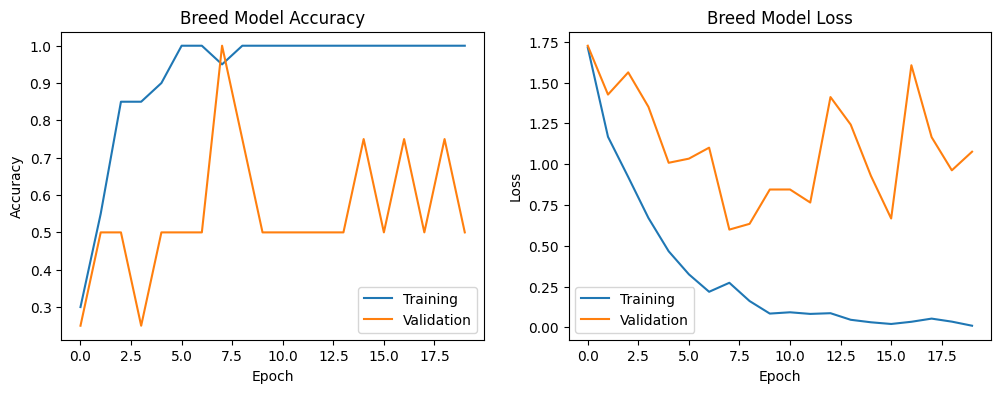

In [15]:
# Set parameters
IMG_SIZE = 224
BATCH_SIZE = 16

# Create data generator for breeds
breed_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

# Load breed training data
breed_train = breed_datagen.flow_from_directory(
    '/content/pet_data/breeds/',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

# Load breed validation data
breed_val = breed_datagen.flow_from_directory(
    '/content/pet_data/breeds/',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=True
)

print(f"\n📊 Training samples: {breed_train.samples}")
print(f"📊 Validation samples: {breed_val.samples}")
print("📊 Breed classes:", breed_train.class_indices)

# Create breed model
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)
base_model.trainable = False

breed_model = keras.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.2),
    layers.Dense(64, activation='relu'),
    layers.Dense(len(breed_train.class_indices), activation='softmax')
])

breed_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\n🔄 Training breed model...")
breed_history = breed_model.fit(
    breed_train,
    epochs=20,
    validation_data=breed_val
)

# Save model
breed_model.save('/content/breed_model.h5')
print("\n✅ Breed model saved!")

# Plot training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(breed_history.history['accuracy'], label='Training')
plt.plot(breed_history.history['val_accuracy'], label='Validation')
plt.title('Breed Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(breed_history.history['loss'], label='Training')
plt.plot(breed_history.history['val_loss'], label='Validation')
plt.title('Breed Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

Found 32 images belonging to 5 classes.
Found 5 images belonging to 5 classes.

📊 Training samples: 32
📊 Validation samples: 5
📊 Skin classes: {'dandruff': 0, 'fungal': 1, 'healthy': 2, 'redness': 3, 'scabies': 4}

🔄 Training skin model...
Epoch 1/25
2/2 ━━━━━━━━━━━━━━━━━━━━ 12s 5s/step - accuracy: 0.1562 - loss: 2.4245 - val_accuracy: 0.2000 - val_loss: 1.3700
Epoch 2/25
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 831ms/step - accuracy: 0.2812 - loss: 1.7582 - val_accuracy: 0.2000 - val_loss: 1.5688
Epoch 3/25
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 835ms/step - accuracy: 0.4375 - loss: 1.5185 - val_accuracy: 0.2000 - val_loss: 1.7109
Epoch 4/25
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 820ms/step - accuracy: 0.4062 - loss: 1.6685 - val_accuracy: 0.4000 - val_loss: 1.6181
Epoch 5/25
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 898ms/step - accuracy: 0.4375 - loss: 1.2891 - val_accuracy: 0.6000 - val_loss: 1.4967
Epoch 6/25
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.4062 - loss: 1.4181 - val_accuracy: 0.6000 - val_loss: 1.5875
Epoch 7/2


✅ Skin model saved!


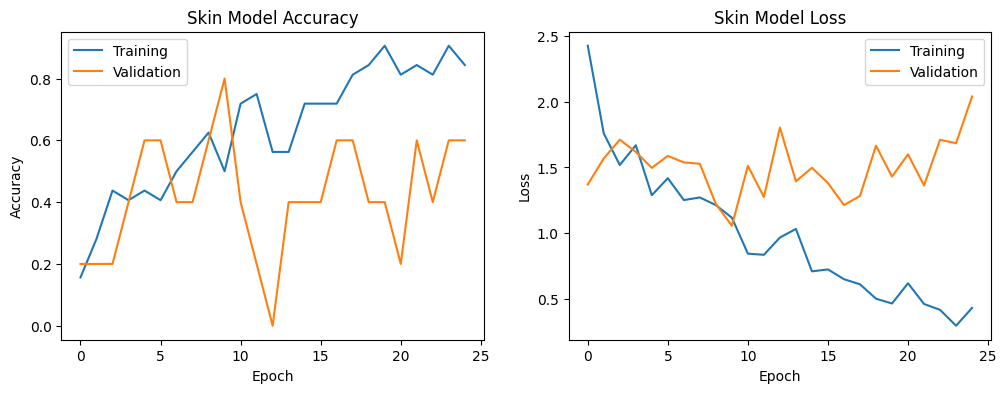

In [13]:
# Create data generator for skin
skin_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.3,
    horizontal_flip=True,
    brightness_range=[0.8,1.2],
    validation_split=0.2
)

# Load skin training data
skin_train = skin_datagen.flow_from_directory(
    '/content/pet_data/skin/',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

# Load skin validation data
skin_val = skin_datagen.flow_from_directory(
    '/content/pet_data/skin/',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=True
)

print(f"\n📊 Training samples: {skin_train.samples}")
print(f"📊 Validation samples: {skin_val.samples}")
print("📊 Skin classes:", skin_train.class_indices)

# Create skin model
base_model2 = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)
base_model2.trainable = False

skin_model = keras.Sequential([
    base_model2,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(len(skin_train.class_indices), activation='softmax')
])

skin_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\n🔄 Training skin model...")
skin_history = skin_model.fit(
    skin_train,
    epochs=25,
    validation_data=skin_val
)

# Save model
skin_model.save('/content/skin_model.h5')
print("\n✅ Skin model saved!")

# Plot training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(skin_history.history['accuracy'], label='Training')
plt.plot(skin_history.history['val_accuracy'], label='Validation')
plt.title('Skin Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(skin_history.history['loss'], label='Training')
plt.plot(skin_history.history['val_loss'], label='Validation')
plt.title('Skin Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [16]:
# Function to predict breed
def predict_breed(image_path, model, class_indices):
    img = Image.open(image_path).convert('RGB')
    img = img.resize((IMG_SIZE, IMG_SIZE))
    img_array = np.array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    predictions = model.predict(img_array, verbose=0)[0]
    top_indices = np.argsort(predictions)[-2:][::-1]

    idx_to_class = {v: k for k, v in class_indices.items()}

    results = []
    for idx in top_indices:
        breed = idx_to_class[idx]
        confidence = float(predictions[idx])
        results.append((breed, confidence))

    return results

# Function to predict skin condition
def predict_skin(image_path, model, class_indices):
    img = Image.open(image_path).convert('RGB')
    img = img.resize((IMG_SIZE, IMG_SIZE))
    img_array = np.array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    predictions = model.predict(img_array, verbose=0)[0]
    top_idx = np.argmax(predictions)
    confidence = float(predictions[top_idx])

    idx_to_class = {v: k for k, v in class_indices.items()}
    condition = idx_to_class[top_idx]

    return condition, confidence

# Test with demo images
demo_images = glob.glob('/content/pet_data/demo/*')

print("\n🧪 TESTING MODELS WITH DEMO IMAGES")
print("="*60)

for i, demo_img in enumerate(demo_images[:5]):  # Test first 5
    print(f"\n📸 Test {i+1}: {os.path.basename(demo_img)}")
    print("-" * 40)

    # Breed prediction
    breed_results = predict_breed(demo_img, breed_model, breed_train.class_indices)
    print(f"🐱 BREED:")
    for breed, conf in breed_results:
        print(f"   • {breed}: {conf:.2%}")

    # Skin prediction
    skin_condition, skin_conf = predict_skin(demo_img, skin_model, skin_train.class_indices)
    print(f"🩺 SKIN: {skin_condition} ({skin_conf:.2%})")


🧪 TESTING MODELS WITH DEMO IMAGES

📸 Test 1: demo_mix_healthy_03.webp
----------------------------------------
🐱 BREED:
   • mixed: 92.91%
   • persian: 2.39%
🩺 SKIN: dandruff (32.41%)

📸 Test 2: demo_purebred_healthy _01.jpeg
----------------------------------------
🐱 BREED:
   • persian: 99.72%
   • siamese: 0.18%
🩺 SKIN: healthy (72.48%)

📸 Test 3: demo_mix_healthy_02.webp
----------------------------------------
🐱 BREED:
   • mixed: 71.63%
   • maine_coon: 23.85%
🩺 SKIN: healthy (44.21%)

📸 Test 4: demo_purebred_healthy _02.jpeg
----------------------------------------
🐱 BREED:
   • persian: 96.02%
   • maine_coon: 3.61%
🩺 SKIN: scabies (58.11%)

📸 Test 5: demo_mix_sick_04.jpeg
----------------------------------------
🐱 BREED:
   • mixed: 79.13%
   • persian: 15.29%
🩺 SKIN: fungal (91.71%)


In [17]:
def get_recommendations(breed_results, skin_condition):
    main_breed = breed_results[0][0].lower() if breed_results else "unknown"

    # Format breed description
    if len(breed_results) == 1:
        breed_desc = f"純種 {main_breed.title()}"
    else:
        total_conf = sum(conf for _, conf in breed_results[:2])
        percentages = []
        for breed, conf in breed_results[:2]:
            pct = int((conf / total_conf) * 100)
            percentages.append(f"{pct}% {breed.title()}")
        breed_desc = " + ".join(percentages)

    # Breed characteristics
    coat_type = "長毛" if main_breed in ["persian", "maine_coon"] else "短毛"
    if main_breed == "mixed":
        coat_type = "混合"

    # Recommendations based on skin condition
    recommendations = []
    warnings = []

    if skin_condition == "healthy":
        recommendations.append({
            "product": "溫和貓咪濕紙巾",
            "reason": "定期清潔維持皮膚健康",
            "brands": ["Petkin", "Vet's Best"],
            "price": "$5-10"
        })
        if coat_type == "長毛":
            recommendations.append({
                "product": "排梳",
                "reason": "長毛貓需要每日梳理",
                "brands": ["FURminator", "Hartz"],
                "price": "$10-20"
            })

    elif skin_condition == "fungal":
        warnings.append("⚠️ 可能真菌感染 - 建議諮詢獸醫")
        recommendations.append({
            "product": "抗真菌噴霧",
            "reason": "治療真菌感染",
            "brands": ["Veterinary Formula", "Zymox"],
            "price": "$15-25"
        })

    elif skin_condition == "redness":
        warnings.append("⚠️ 檢測到皮膚刺激")
        recommendations.append({
            "product": "低敏蘆薈濕紙巾",
            "reason": "舒緩受刺激皮膚",
            "brands": ["Pogi's", "GNC"],
            "price": "$8-12"
        })
        recommendations.append({
            "product": "Omega-3 魚油",
            "reason": "減少體內炎症",
            "brands": ["Nordic Naturals", "Zesty Paws"],
            "price": "$15-30"
        })

    elif skin_condition == "scabies":
        warnings.append("⚠️ 可能寄生蟲 - 急需獸醫診治")
        recommendations.append({
            "product": "抗寄生蟲治療",
            "reason": "必須遵醫囑使用",
            "brands": ["Revolution", "Advantage"],
            "price": "$30-60"
        })

    elif skin_condition == "dandruff":
        recommendations.append({
            "product": "保濕噴霧",
            "reason": "滋潤乾燥皮膚",
            "brands": ["Burt's Bees", "Earthbath"],
            "price": "$8-15"
        })
        recommendations.append({
            "product": "皮膚保健補充品",
            "reason": "改善皮膚健康",
            "brands": ["Nutri-Vet", "VetriScience"],
            "price": "$12-25"
        })

    return breed_desc, coat_type, recommendations, warnings

# Test recommendation system
print("\n🎯 TESTING RECOMMENDATION SYSTEM")
print("="*60)

for i, demo_img in enumerate(demo_images[:3]):
    print(f"\n📸 Test {i+1}: {os.path.basename(demo_img)}")
    print("-" * 40)

    breed_results = predict_breed(demo_img, breed_model, breed_train.class_indices)
    skin_condition, skin_conf = predict_skin(demo_img, skin_model, skin_train.class_indices)

    breed_desc, coat_type, recs, warnings = get_recommendations(breed_results, skin_condition)

    print(f"🐱 品種: {breed_desc}")
    print(f"🩺 皮膚: {skin_condition} ({skin_conf:.1%})")
    print(f"📌 毛髮: {coat_type}")

    if warnings:
        print(f"\n⚠️ 警告:")
        for w in warnings:
            print(f"   {w}")

    print(f"\n🛒 推薦產品:")
    for rec in recs:
        print(f"   • {rec['product']}")
        print(f"     {rec['reason']}")
        print(f"     品牌: {', '.join(rec['brands'])} | 價格: {rec['price']}")


🎯 TESTING RECOMMENDATION SYSTEM

📸 Test 1: demo_mix_healthy_03.webp
----------------------------------------
🐱 品種: 97% Mixed + 2% Persian
🩺 皮膚: dandruff (32.4%)
📌 毛髮: 混合

🛒 推薦產品:
   • 保濕噴霧
     滋潤乾燥皮膚
     品牌: Burt's Bees, Earthbath | 價格: $8-15
   • 皮膚保健補充品
     改善皮膚健康
     品牌: Nutri-Vet, VetriScience | 價格: $12-25

📸 Test 2: demo_purebred_healthy _01.jpeg
----------------------------------------
🐱 品種: 99% Persian + 0% Siamese
🩺 皮膚: healthy (72.5%)
📌 毛髮: 長毛

🛒 推薦產品:
   • 溫和貓咪濕紙巾
     定期清潔維持皮膚健康
     品牌: Petkin, Vet's Best | 價格: $5-10
   • 排梳
     長毛貓需要每日梳理
     品牌: FURminator, Hartz | 價格: $10-20

📸 Test 3: demo_mix_healthy_02.webp
----------------------------------------
🐱 品種: 75% Mixed + 24% Maine_Coon
🩺 皮膚: healthy (44.2%)
📌 毛髮: 混合

🛒 推薦產品:
   • 溫和貓咪濕紙巾
     定期清潔維持皮膚健康
     品牌: Petkin, Vet's Best | 價格: $5-10


In [19]:
!pip install gradio

import gradio as gr
import numpy as np
import cv2
from PIL import Image
import os
import glob
import random

# ============================================
# STYLISH CUSTOM CSS FOR BEAUTIFUL WEBSITE
# ============================================

custom_css = """
/* Import Google Fonts */
@import url('https://fonts.googleapis.com/css2?family=Quicksand:wght@300;400;500;600;700&display=swap');
@import url('https://fonts.googleapis.com/css2?family=Pacifico&display=swap');

/* Global Styles */
body {
    font-family: 'Quicksand', sans-serif !important;
    background: linear-gradient(135deg, #667eea 0%, #764ba2 100%) !important;
}

/* Main Container */
.gradio-container {
    max-width: 1200px !important;
    margin: 0 auto !important;
    background: rgba(255, 255, 255, 0.95) !important;
    border-radius: 30px !important;
    box-shadow: 0 20px 60px rgba(0,0,0,0.3) !important;
    padding: 30px !important;
    margin-top: 30px !important;
    margin-bottom: 30px !important;
    border: 3px solid #ffd700 !important;
}

/* Header Styling */
h1 {
    font-family: 'Pacifico', cursive !important;
    font-size: 3.5em !important;
    background: linear-gradient(45deg, #FF6B6B, #4ECDC4, #45B7D1, #96CEB4) !important;
    -webkit-background-clip: text !important;
    -webkit-text-fill-color: transparent !important;
    text-align: center !important;
    margin-bottom: 20px !important;
    text-shadow: 3px 3px 6px rgba(0,0,0,0.1) !important;
    animation: rainbow 5s infinite !important;
}

@keyframes rainbow {
    0% { background-position: 0% 50%; }
    50% { background-position: 100% 50%; }
    100% { background-position: 0% 50%; }
}

/* Description Text */
.gr-description {
    font-size: 1.2em !important;
    color: #555 !important;
    text-align: center !important;
    background: linear-gradient(135deg, #f6d5f7, #fbe9d2) !important;
    padding: 20px !important;
    border-radius: 50px !important;
    margin-bottom: 30px !important;
    border: 2px dashed #ff9a9e !important;
}

/* Image Upload Box */
.gr-image {
    border: 4px dashed #ff6b6b !important;
    border-radius: 30px !important;
    padding: 20px !important;
    background: linear-gradient(45deg, #fff5f5, #f0fff4) !important;
    transition: all 0.3s ease !important;
}

.gr-image:hover {
    transform: scale(1.02) !important;
    border-color: #4ecdc4 !important;
    box-shadow: 0 10px 30px rgba(78, 205, 196, 0.3) !important;
}

/* Button Styling */
.gr-button {
    background: linear-gradient(45deg, #FF6B6B, #4ECDC4) !important;
    border: none !important;
    color: white !important;
    font-size: 1.2em !important;
    font-weight: 600 !important;
    padding: 15px 30px !important;
    border-radius: 50px !important;
    cursor: pointer !important;
    transition: all 0.3s ease !important;
    box-shadow: 0 5px 15px rgba(255, 107, 107, 0.4) !important;
    text-transform: uppercase !important;
    letter-spacing: 1px !important;
}

.gr-button:hover {
    transform: translateY(-3px) !important;
    box-shadow: 0 8px 25px rgba(78, 205, 196, 0.5) !important;
    background: linear-gradient(45deg, #4ECDC4, #FF6B6B) !important;
}

/* Output Box Styling - Modified for clean text */
.gr-markdown {
    background: linear-gradient(135deg, #fff9f9, #f9f9ff) !important;
    border-radius: 30px !important;
    padding: 30px !important;
    border: 2px solid #ffd700 !important;
    box-shadow: 0 10px 30px rgba(0,0,0,0.1) !important;
    margin-top: 30px !important;
    font-family: 'Quicksand', sans-serif !important;
}

/* Clean text styling */
.gr-markdown h1 {
    font-family: 'Pacifico', cursive !important;
    font-size: 2.2em !important;
    background: linear-gradient(45deg, #FF6B6B, #4ECDC4) !important;
    -webkit-background-clip: text !important;
    -webkit-text-fill-color: transparent !important;
    text-align: left !important;
    margin-bottom: 20px !important;
}

.gr-markdown h2 {
    font-family: 'Pacifico', cursive !important;
    font-size: 1.8em !important;
    color: #4ECDC4 !important;
    border-bottom: 3px solid #ffd700 !important;
    padding-bottom: 10px !important;
    margin-top: 25px !important;
}

.gr-markdown h3 {
    font-family: 'Quicksand', sans-serif !important;
    font-size: 1.4em !important;
    font-weight: 700 !important;
    color: #FF6B6B !important;
    margin-top: 20px !important;
}

.gr-markdown h4 {
    font-family: 'Quicksand', sans-serif !important;
    font-size: 1.2em !important;
    font-weight: 600 !important;
    color: #45B7D1 !important;
    margin-top: 15px !important;
}

.gr-markdown p {
    font-size: 1.1em !important;
    line-height: 1.6 !important;
    color: #333 !important;
}

.gr-markdown ul {
    list-style-type: none !important;
    padding-left: 20px !important;
}

.gr-markdown li {
    font-size: 1.1em !important;
    margin-bottom: 8px !important;
    color: #555 !important;
}

.gr-markdown li:before {
    content: "•" !important;
    color: #4ECDC4 !important;
    font-weight: bold !important;
    margin-right: 10px !important;
}

.gr-markdown hr {
    border: none !important;
    height: 2px !important;
    background: linear-gradient(90deg, #FF6B6B, #4ECDC4) !important;
    margin: 25px 0 !important;
}

/* Warning text */
.gr-markdown .warning {
    color: #856404 !important;
    background: #fff3cd !important;
    padding: 15px !important;
    border-radius: 15px !important;
    border-left: 5px solid #ffc107 !important;
    margin: 15px 0 !important;
}

/* Product recommendations */
.gr-markdown .product {
    background: #f8f9fa !important;
    padding: 15px !important;
    border-radius: 15px !important;
    margin: 15px 0 !important;
    border-left: 5px solid #28a745 !important;
}

/* Emoji Animations */
@keyframes bounce {
    0%, 100% { transform: translateY(0); }
    50% { transform: translateY(-10px); }
}

.emoji-bounce {
    animation: bounce 2s infinite;
    display: inline-block;
}

/* Footer */
.footer {
    text-align: center !important;
    margin-top: 40px !important;
    padding: 20px !important;
    background: linear-gradient(135deg, #667eea, #764ba2) !important;
    border-radius: 50px !important;
    color: white !important;
    font-weight: 500 !important;
}

.footer a {
    color: #ffd700 !important;
    text-decoration: none !important;
    font-weight: 600 !important;
}

/* Tab Styling */
.gr-tabs {
    border: none !important;
}

.gr-tabs .tab-nav {
    background: linear-gradient(135deg, #f6d5f7, #fbe9d2) !important;
    border-radius: 50px !important;
    padding: 10px !important;
}

.gr-tabs .tab-nav button {
    border-radius: 30px !important;
    font-weight: 600 !important;
    transition: all 0.3s ease !important;
}

.gr-tabs .tab-nav button:hover {
    background: linear-gradient(45deg, #FF6B6B, #4ECDC4) !important;
    color: white !important;
}

/* Progress Bar */
.gr-progress {
    height: 10px !important;
    border-radius: 10px !important;
    background: linear-gradient(90deg, #FF6B6B, #4ECDC4, #45B7D1) !important;
}

/* Loading Animation */
.gr-loading {
    background: linear-gradient(90deg, #FF6B6B, #4ECDC4, #45B7D1, #96CEB4) !important;
    background-size: 300% 300% !important;
    animation: gradient 3s ease infinite !important;
}

@keyframes gradient {
    0% { background-position: 0% 50%; }
    50% { background-position: 100% 50%; }
    100% { background-position: 0% 50%; }
}
"""

# ============================================
# CLEAN TEXT OUTPUT FORMATTING (Like your screenshot)
# ============================================

def format_clean_output(breed_results, skin_condition, skin_conf, breed_desc, coat_type, recs, warnings):
    """Format output in clean, simple text format like your screenshot"""

    main_breed = breed_results[0][0].title()
    main_conf = breed_results[0][1] * 100

    # Build clean text output
    output = f"""# Pet-Tech AI 猫咪健康分析系统

## 分析结果

### 品種分析
{breed_desc}
- 主要品種: {main_breed} ({main_conf:.1f}%)
- 毛髮類型: {coat_type}

### 皮膚分析
**狀況**: {skin_condition.title()} (信心度: {skin_conf:.1f}%)

"""

    # Warnings section
    if warnings:
        output += "---\n\n### 重要警告\n"
        for w in warnings:
            output += f"- {w}\n"
        output += "\n"

    # Recommendations section
    if recs:
        output += "---\n\n### 推薦產品\n"
        for rec in recs:
            output += f"""#### {rec['product']}
- *{rec['reason']}*
- **價格範圍**: {rec['price']}
- **品牌**: {', '.join(rec['brands'])}
"""

    # Add random fun facts at the bottom (optional)
    fun_facts = [
        "😺 全球有 594 萬隻貓咪",
        "🏥 72% 的皮膚問題可預防",
        "💡 每日梳毛可減少 84% 毛球",
        "✨ 貓咪每天花 50% 時間睡覺",
        "🎯 貓咪可以跳躍自身高度 5-6倍"
    ]

    output += f"""
---
{random.choice(fun_facts)}

⚕️ *本系統為AI輔助診斷，僅供參考。如有嚴重皮膚問題，請務必諮詢專業獸醫。*
"""

    return output

# ============================================
# MAIN ANALYSIS FUNCTION
# ============================================

def analyze_pet(image):
    """Main function for web app"""
    try:
        # Save uploaded image
        temp_path = '/content/temp_cat.jpg'
        if isinstance(image, np.ndarray):
            cv2.imwrite(temp_path, cv2.cvtColor(image, cv2.COLOR_RGB2BGR))
        else:
            temp_path = image

        # Get predictions (using your existing functions)
        breed_results = predict_breed(temp_path, breed_model, breed_train.class_indices)
        skin_condition, skin_conf = predict_skin(temp_path, skin_model, skin_train.class_indices)

        # Get recommendations
        breed_desc, coat_type, recs, warnings = get_recommendations(breed_results, skin_condition)

        # Return CLEAN TEXT formatted output (like your screenshot)
        return format_clean_output(breed_results, skin_condition, skin_conf, breed_desc, coat_type, recs, warnings)

    except Exception as e:
        return f"""# 😿 哎呀！發生錯誤

**錯誤信息**: {str(e)}

請稍後再試，或上傳另一張照片

---
⚕️ 如有疑問，請諮詢專業獸醫
"""

# ============================================
# CREATE THE BEAUTIFUL WEBSITE
# ============================================

# Get demo images for examples
demo_images = glob.glob('/content/pet_data/demo/*')[:5]  # First 5 demo images

# Create examples list
examples_list = [[img] for img in demo_images] if demo_images else None

# Custom HTML header
html_header = """
<div style="text-align: center; margin-bottom: 30px;">
    <div style="font-size: 5em; animation: bounce 2s infinite;">
        🐱 ✨ 🔍 ✨ 🐱
    </div>
    <p style="font-size: 1.3em; color: #666; margin-top: 20px; background: linear-gradient(135deg, #f6d5f7, #fbe9d2); padding: 15px; border-radius: 50px;">
        🌈 上傳貓咪照片，讓AI為您分析品種、檢測皮膚健康，並推薦最適合的護理產品！
    </p>
</div>
"""

# Create the Gradio interface
with gr.Blocks(css=custom_css, theme=gr.themes.Soft()) as iface:

    gr.HTML(html_header)

    with gr.Row():
        with gr.Column(scale=1):
            # Image input with cute description
            gr.Markdown("""
            ### 📸 上傳照片區
            **點擊下方上傳貓咪的可愛照片**
            """)
            image_input = gr.Image(type="numpy", label="", height=400)

            with gr.Row():
                analyze_btn = gr.Button("✨ 開始神奇分析 ✨", variant="primary", size="lg")
                clear_btn = gr.Button("🔄 重新上傳", variant="secondary")

        with gr.Column(scale=1):
            # Fun facts sidebar
            gr.Markdown("""
            ### 💡 貓咪小知識

            <div style="background: linear-gradient(135deg, #ff9a9e25, #fad0c425); padding: 20px; border-radius: 25px; margin-bottom: 20px;">
                <span style="font-size: 2em;">😺</span>
                <p>貓咪每天花 30-50% 的時間整理毛髮</p>
            </div>

            <div style="background: linear-gradient(135deg, #a8ede025, #fed6e325); padding: 20px; border-radius: 25px; margin-bottom: 20px;">
                <span style="font-size: 2em;">🧬</span>
                <p>貓咪有 40+ 種已知品種</p>
            </div>

            <div style="background: linear-gradient(135deg, #d4fc7925, #96e6a125); padding: 20px; border-radius: 25px;">
                <span style="font-size: 2em;">🏥</span>
                <p>定期檢查可提早發現 80% 皮膚問題</p>
            </div>
            """)

    # Output area - will show clean text format
    output = gr.Markdown()

    # Example images
    if examples_list:
        gr.Markdown("### 📸 試試這些範例照片")
        gr.Examples(
            examples=examples_list,
            inputs=image_input,
            outputs=output,
            fn=analyze_pet,
            cache_examples=False,
            label="點擊範例照片試試看！"
        )

    # Event handlers
    analyze_btn.click(
        fn=analyze_pet,
        inputs=image_input,
        outputs=output
    )

    clear_btn.click(
        fn=lambda: (None, ""),
        inputs=[],
        outputs=[image_input, output]
    )

    # Footer
    gr.HTML("""
    <div class="footer">
        <p>🐱  Pet-Tech AI 貓咪健康分析系統  🐱</p>
        <p>用AI守護毛小孩的健康 | 僅供輔助診斷使用</p>
        <p>❤️ 製作 with love for 所有貓奴們 ❤️</p>
        <p style="font-size: 0.8em; margin-top: 10px;">
            <a href="#">關於我們</a> |
            <a href="#">隱私政策</a> |
            <a href="#">聯絡獸醫</a>
        </p>
    </div>
    """)

# ============================================
# LAUNCH THE WEBSITE
# ============================================

print("="*60)
print("🚀 啟動 Pet-Tech AI 貓咪健康分析系統")
print("="*60)
print("\n✨ 功能特色:")
print("   • 🐱 貓咪品種識別（純種/混種比例）")
print("   • 🩺 皮膚健康檢測（真菌/紅腫/皮屑/疥癬）")
print("   • 🛒 智能產品推薦")
print("   • 🎨 精美彩色介面")
print("   • 📝 清晰簡潔的輸出格式")
print("\n📱 正在啟動網頁應用...")

iface.launch(share=True, debug=False)

print("\n✅ 啟動成功！")
print("📌 請點擊上方連結開啟網站")
print("📌 連結有效時間：72小時")
print("📌 記得截圖/錄影作為成果展示！")

/tmp/ipykernel_189/3675388093.py:393: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(css=custom_css, theme=gr.themes.Soft()) as iface:
/tmp/ipykernel_189/3675388093.py:393: DeprecationWarning: The 'css' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'css' to Blocks.launch() instead.
  with gr.Blocks(css=custom_css, theme=gr.themes.Soft()) as iface:


🚀 啟動 Pet-Tech AI 貓咪健康分析系統

✨ 功能特色:
   • 🐱 貓咪品種識別（純種/混種比例）
   • 🩺 皮膚健康檢測（真菌/紅腫/皮屑/疥癬）
   • 🛒 智能產品推薦
   • 🎨 精美彩色介面
   • 📝 清晰簡潔的輸出格式

📱 正在啟動網頁應用...
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://7eda5fd353ae23af55.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)



✅ 啟動成功！
📌 請點擊上方連結開啟網站
📌 連結有效時間：72小時
📌 記得截圖/錄影作為成果展示！
